In [3]:
# The first step is to load some standard python packages (numpy, pandas, scipy and matplotlib.pyplot).
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
import scipy.stats as stats
import warnings
warnings.simplefilter('ignore') # filter some warning messages
from matplotlib.dates import DateFormatter
from datetime import timedelta

In [23]:
depths = np.arange(1,401) # note the depth might need to be increased depending on the location and corresponding extreme rainfall and the duration
columns = ['n_occ_1day', 'n_ex_1day', 'r_ex_1day', 'T_1day', 
           'n_occ_2day', 'n_ex_2day', 'r_ex_2day', 'T_2day', 
           'n_occ_5day', 'n_ex_5day', 'r_ex_5day', 'T_5day']
frequency_df = pd.DataFrame(index=depths, columns=columns)
frequency_df.index.name = 'sum(R) (mm)'
frequency_df

,n_occ_1day,n_ex_1day,r_ex_1day,T_1day,n_occ_2day,n_ex_2day,r_ex_2day,T_2day,n_occ_5day,n_ex_5day,r_ex_5day,T_5day
sum(R) (mm),,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
def data(filename):
    df = pd.read_csv(filename, parse_dates=['time'], index_col='time')
    return df

In [22]:
rainfall_Black_Volta = data('mswep/Black_Volta.csv')
sum_rainfall = rainfall_Black_Volta.resample('M').sum()
print(sum_rainfall.max())

precipitation    308.5
dtype: float64


<Axes: xlabel='time'>

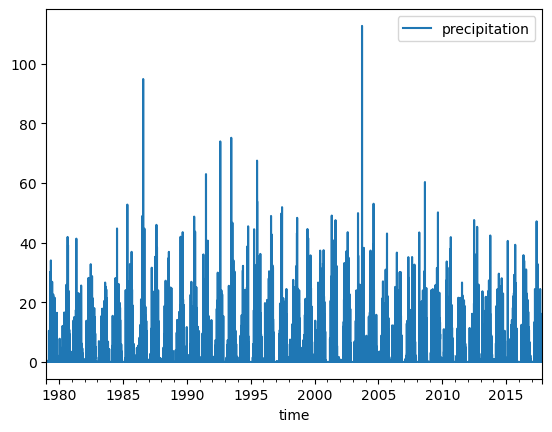

In [24]:
rainfall_Black_Volta.plot()

In [28]:
rainfall_Black_Volta_new = (np.maximum(rainfall_Black_Volta, 0)).copy()
rainfall_Black_Volta_new = rainfall_Black_Volta_new.rename(columns={"precipitation": "R-1day"})
rainfall_Black_Volta_new

,R-1day
time,
1979-01-01,0.0
1979-01-02,0.0
1979-01-03,0.0
1979-01-04,0.0
1979-01-05,0.0
...,...
2017-10-27,0.0
2017-10-28,0.0
2017-10-29,0.0


<Axes: xlabel='daily precipitation sum [mm]', ylabel='Frequency'>

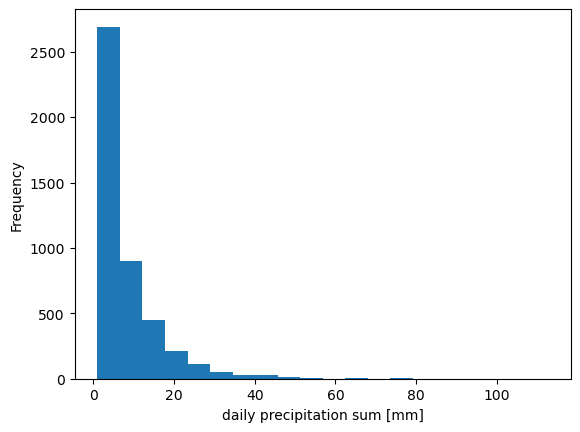

In [29]:
# remove all values below 1 mm/day and save as separate column
rainfall_Black_Volta_new['R-1day-nonzero'] = rainfall_Black_Volta_new['R-1day']
rainfall_Black_Volta_new['R-1day-nonzero'][rainfall_Black_Volta_new['R-1day-nonzero'] < 1] = np.nan

# plot the histogram based on previous lecture to verify the data looks as expected
rainfall_Black_Volta_new['R-1day-nonzero'].plot.hist(xlabel="daily precipitation sum [mm]", bins=20)

In [31]:
# extract the actual values from the timeseries
R_1_day_nonzero = rainfall_Black_Volta_new['R-1day-nonzero'].values

# compute the count and the bin edges (including left and right edges)
extended_bin_edges = np.append(depths, depths[-1] + depths[-1]-depths[-2])
count, bin_edges_check = np.histogram(R_1_day_nonzero, bins=extended_bin_edges)

# validate that our anticipated bin_edges indeed incorporated all data
print('the bin edge was ' + str(bin_edges_check[-1]) + ' mm, and the actual max precipitation value was ' + str(np.nanmax(R_1_day_nonzero)) + ' mm')

# put this back in the original dataframe 'frequency_df'
frequency_df['n_occ_1day'] = count
frequency_df
# inspect a specific relevant part of the dataframe containing the extremes
#frequency_df[55:65]

the bin edge was 401 mm, and the actual max precipitation value was 112.73 mm


,n_occ_1day,n_ex_1day,r_ex_1day,T_1day,n_occ_2day,n_ex_2day,r_ex_2day,T_2day,n_occ_5day,n_ex_5day,r_ex_5day,T_5day
sum(R) (mm),,,,,,,,,,,,
1,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
396,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
398,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# total number of years
d = len(rainfall_Black_Volta_new)
# N = len(rainfall_Black_Volta_new.resample('Y').sum())
N = d / 365.25
print('total number of years N = ' + str(N))

# STUDENT: calculate exceedances, rate and return period.
n_occ_1day = frequency_df['n_occ_1day'].values
n_ex_1day = np.zeros(n_occ_1day.shape)
for n in np.arange(len(n_occ_1day)):
    n_ex_1day[n] = np.sum(n_occ_1day[n:])
#print(n_ex_1day)

r_ex_1day = n_ex_1day/N

T_1day = 1/r_ex_1day
frequency_df['n_ex_1day'] = n_ex_1day
frequency_df['r_ex_1day'] = r_ex_1day
frequency_df['T_1day'] = T_1day
frequency_df[0:10]


total number of years N = 38.83367556468173


,n_occ_1day,n_ex_1day,r_ex_1day,T_1day,n_occ_2day,n_ex_2day,r_ex_2day,T_2day,n_occ_5day,n_ex_5day,r_ex_5day,T_5day
sum(R) (mm),,,,,,,,,,,,
1,919,4490.0,115.621299,0.008649,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,597,3571.0,91.956271,0.010875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,440,2974.0,76.583016,0.013058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,319,2534.0,65.252644,0.015325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,277,2215.0,57.038124,0.017532,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,236,1938.0,49.905140,0.020038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,193,1702.0,43.827940,0.022816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,141,1509.0,38.858027,0.025735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,164,1368.0,35.227157,0.028387,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# resample the precipitation to 2 and 5 days, which is rather straightforward using pandas resample methods
R_2day = rainfall_Black_Volta_new['R-1day'].resample("2d", offset="0d").sum()
rainfall_Black_Volta_new['R_2day'] = R_2day
rainfall_Black_Volta_new.head(20)
# as you can see the only non-intuitive thing is that the resample gets assigned the date of the first day, 
# whereas with precipitation we have accumulated values, making this not logical, however this will not effect the further results
# Note that masking the values below 1 mm is not necessary, as this can be done automatically with the bin settings of np.histogram.

,R-1day,R-1day-nonzero,R_2day
time,,,
1979-01-01,0.00,NaN,0.00
1979-01-02,0.00,NaN,NaN
1979-01-03,0.00,NaN,0.00
1979-01-04,0.00,NaN,NaN
1979-01-05,0.00,NaN,0.00
1979-01-06,0.00,NaN,NaN
1979-01-07,0.00,NaN,0.00
1979-01-08,0.00,NaN,NaN
1979-01-09,0.00,NaN,0.00


In [40]:
# STUDENT:
# resample for 5 days
R_5day = rainfall_Black_Volta_new['R-1day'].resample("5d", offset="0d").sum()
rainfall_Black_Volta_new['R_5day'] = R_5day
rainfall_Black_Volta_new.head(20)

,R-1day,R-1day-nonzero,R_2day,R_5day
time,,,,
1979-01-01,0.00,NaN,0.00,0.00
1979-01-02,0.00,NaN,NaN,NaN
1979-01-03,0.00,NaN,0.00,NaN
1979-01-04,0.00,NaN,NaN,NaN
1979-01-05,0.00,NaN,0.00,NaN
1979-01-06,0.00,NaN,NaN,0.00
1979-01-07,0.00,NaN,0.00,NaN
1979-01-08,0.00,NaN,NaN,NaN
1979-01-09,0.00,NaN,0.00,NaN


In [41]:
# STUDENT:
# Repeat the exceedances for 2 day precipitation
count, bin_edges_check = np.histogram(R_2day, bins=extended_bin_edges)

# validate that our anticipated bin_edges indeed incorporated all data
print('the max bin edge was ' + str(bin_edges_check[-1]) + ' mm, and the actual max precipitation value was ' + str(np.nanmax(R_2day)) + ' mm')

# put this back in the original dataframe 'frequency_df'
frequency_df['n_occ_2day'] = count

the max bin edge was 401 mm, and the actual max precipitation value was 112.73 mm


In [42]:
# STUDENT:
# Repeat the exceedances for 5 day precipitation
count, bin_edges_check = np.histogram(R_5day, bins=extended_bin_edges)

# validate that our anticipated bin_edges indeed incorporated all data
print('the bin edge was ' + str(bin_edges_check[-1]) + ' mm, and the actual max precipitation value was ' + str(np.nanmax(R_5day)) + ' mm')

# put this back in the original dataframe 'frequency_df'
frequency_df['n_occ_5day'] = count

the bin edge was 401 mm, and the actual max precipitation value was 131.77 mm


In [43]:
# STUDENT:
# calculate exceedances, rate and return period.
n_occ_2day = frequency_df['n_occ_2day'].values
n_ex_2day = np.zeros(n_occ_2day.shape)
for n in np.arange(len(n_occ_2day)):
    n_ex_2day[n] = np.sum(n_occ_2day[n:])
r_ex_2day = n_ex_2day/N
T_2day = 1/r_ex_2day
frequency_df['n_ex_2day'] = n_ex_2day
frequency_df['r_ex_2day'] = r_ex_2day
frequency_df['T_2day'] = T_2day
n_occ_5day = frequency_df['n_occ_5day'].values
n_ex_5day = np.zeros(n_occ_5day.shape)
for n in np.arange(len(n_occ_5day)):
    n_ex_5day[n] = np.sum(n_occ_5day[n:])
r_ex_5day = n_ex_5day/N
T_5day = 1/r_ex_5day
frequency_df['n_ex_5day'] = n_ex_5day
frequency_df['r_ex_5day'] = r_ex_5day
frequency_df['T_5day'] = T_5day
frequency_df[60:70]

,n_occ_1day,n_ex_1day,r_ex_1day,T_1day,n_occ_2day,n_ex_2day,r_ex_2day,T_2day,n_occ_5day,n_ex_5day,r_ex_5day,T_5day
sum(R) (mm),,,,,,,,,,,,
61,0,6.0,0.154505,6.472279,0,12.0,0.309010,3.236140,0,38.0,0.978532,1.021939
62,0,6.0,0.154505,6.472279,0,12.0,0.309010,3.236140,2,38.0,0.978532,1.021939
63,1,6.0,0.154505,6.472279,0,12.0,0.309010,3.236140,1,36.0,0.927030,1.078713
64,0,5.0,0.128754,7.766735,2,12.0,0.309010,3.236140,0,35.0,0.901280,1.109534
65,0,5.0,0.128754,7.766735,1,10.0,0.257508,3.883368,1,35.0,0.901280,1.109534
66,0,5.0,0.128754,7.766735,0,9.0,0.231758,4.314853,1,34.0,0.875529,1.142167
67,1,5.0,0.128754,7.766735,1,9.0,0.231758,4.314853,2,33.0,0.849778,1.176778
68,0,4.0,0.103003,9.708419,1,8.0,0.206007,4.854209,1,31.0,0.798276,1.252699
69,0,4.0,0.103003,9.708419,0,7.0,0.180256,5.547668,5,30.0,0.772525,1.294456


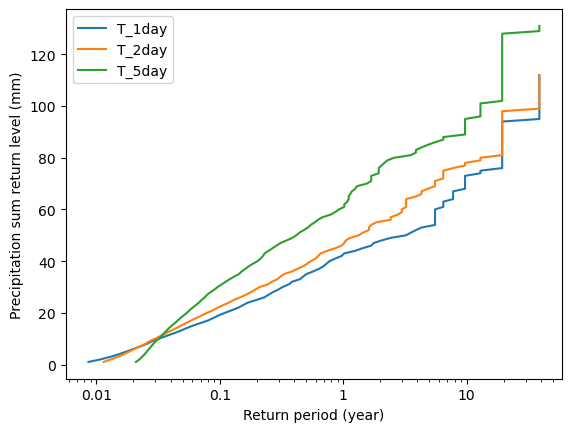

In [44]:
# creating the return level plot
fig, ax = plt.subplots(1)
ax.plot(frequency_df[['T_1day','T_2day','T_5day']].values, frequency_df.index.values)
plt.xlabel('Return period (year)')
plt.ylabel('Precipitation sum return level (mm)')
plt.legend(['T_1day','T_2day','T_5day'])
ax.set_xscale('log')
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda y, _: '{:.16g}'.format(y))
ax.xaxis.set_major_formatter(formatter)

In [45]:
# This empty dataframe provides the idea of what is the desired outcome to plot your data
return_periods = np.array([0.2,0.5,1,2,5,10,20,50]) 
columns = ['R_1day', 'R_2day', 'R_5day']
DDF_df = pd.DataFrame(index=return_periods, columns=columns)
DDF_df.index.name = 'T (years)'
DDF_df

,R_1day,R_2day,R_5day
T (years),,,
0.2,NaN,NaN,NaN
0.5,NaN,NaN,NaN
1.0,NaN,NaN,NaN
2.0,NaN,NaN,NaN
5.0,NaN,NaN,NaN
10.0,NaN,NaN,NaN
20.0,NaN,NaN,NaN
50.0,NaN,NaN,NaN


In [46]:
# find the closest precipitation value for each return period
R_1day = np.empty(return_periods.shape)
for i in np.arange(len(return_periods)):
    return_period = return_periods[i]
    R_1day[i] = frequency_df.iloc[(frequency_df['T_1day'] - return_period).abs().argsort()[:1]].index.values
DDF_df['R_1day'] = R_1day
DDF_df

,R_1day,R_2day,R_5day
T (years),,,
0.2,25.0,NaN,NaN
0.5,35.0,NaN,NaN
1.0,43.0,NaN,NaN
2.0,48.0,NaN,NaN
5.0,57.0,NaN,NaN
10.0,72.0,NaN,NaN
20.0,76.0,NaN,NaN
50.0,97.0,NaN,NaN


In [47]:
# STUDENT: repeat this for 2 and 5 days
R_2day = np.empty(return_periods.shape)
R_5day = np.empty(return_periods.shape)
for i in np.arange(len(return_periods)):
    return_period = return_periods[i]
    R_2day[i] = frequency_df.iloc[(frequency_df['T_2day'] - return_period).abs().argsort()[:1]].index.values
    R_5day[i] = frequency_df.iloc[(frequency_df['T_5day'] - return_period).abs().argsort()[:1]].index.values
DDF_df['R_2day'] = R_2day
DDF_df['R_5day'] = R_5day
DDF_df

,R_1day,R_2day,R_5day
T (years),,,
0.2,25.0,29.0,40.0
0.5,35.0,39.0,53.0
1.0,43.0,47.0,62.0
2.0,48.0,55.0,77.0
5.0,57.0,68.0,85.0
10.0,72.0,77.0,93.0
20.0,76.0,96.0,113.0
50.0,97.0,109.0,129.0


In [48]:
# STUDENT: now create the IDF dataframe
durations = np.array([1, 2, 5])
IDF_df = DDF_df/durations
IDF_df

,R_1day,R_2day,R_5day
T (years),,,
0.2,25.0,14.5,8.0
0.5,35.0,19.5,10.6
1.0,43.0,23.5,12.4
2.0,48.0,27.5,15.4
5.0,57.0,34.0,17.0
10.0,72.0,38.5,18.6
20.0,76.0,48.0,22.6
50.0,97.0,54.5,25.8


Text(0.5, 1.0, 'DDF')

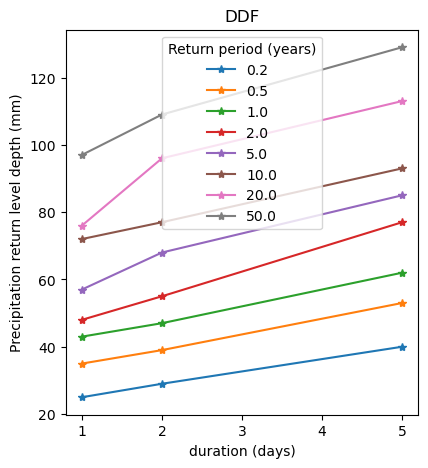

In [49]:
# Plot the DDF and IDF curves
durations = np.array([1, 2, 5])
DDF = DDF_df.transpose(copy=True)
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax1.plot(durations, DDF.values, '-*')
ax1.set_xlabel('duration (days)')
ax1.set_ylabel('Precipitation return level depth (mm)')
ax1.legend(DDF.columns, title='Return period (years)')
ax1.set_title('DDF')

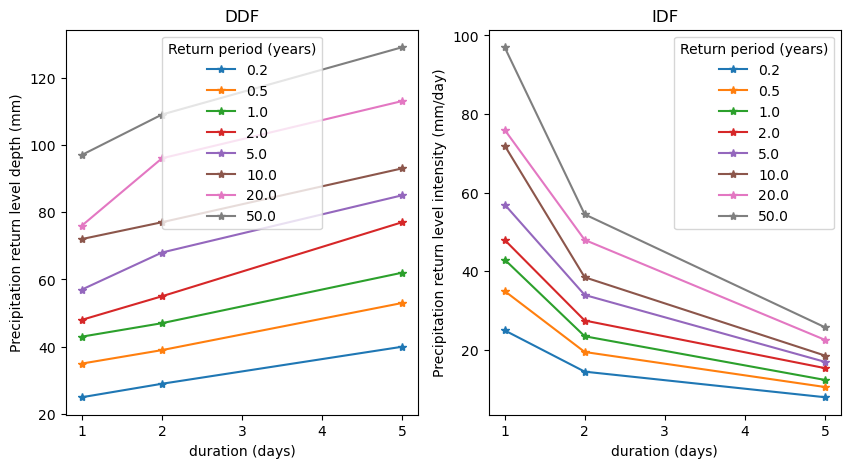

In [50]:
# STUDENT: add the IDF plot with the correct titles, lables and units!
IDF = IDF_df.transpose(copy=True)
ax2 = fig.add_subplot(122)
ax2.plot(durations, IDF.values, '-*')
ax2.set_xlabel('duration (days)')
ax2.set_ylabel('Precipitation return level intensity (mm/day)')
ax2.legend(DDF.columns, title='Return period (years)')
ax2.set_title('IDF')
fig